In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import os
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [19]:
if not os.path.exists('models'):
    os.makedirs('models')

MODEL_PATH = "models/greenkart_xgb.pkl"
COLUMNS_PATH = "models/model_columns.pkl"

In [18]:
# 1. Set a "seed" so random numbers are the same every time we run this
np.random.seed(42)
n_samples = 2000

# 2. Created a Dictionary of random data
data = {
    'material_type': np.random.choice(['Plastic', 'Glass', 'Paper', 'Metal', 'Bamboo'], n_samples),
    'weight_kg': np.random.uniform(0.1, 5.0, n_samples),      # Random weight between 0.1kg and 5kg
    'transport_distance_km': np.random.uniform(10, 1000, n_samples), # Distance between 10km and 1000km
    'is_recyclable': np.random.choice([0, 1], n_samples),     # 0 = No, 1 = Yes
    'energy_efficiency_rating': np.random.choice(['A', 'B', 'C', 'D'], n_samples)
}

# 3. Converted dictionary to a Pandas DataFrame (Table)
df = pd.DataFrame(data)

# Shown the first 5 rows to check if it worked
print("Here is our generated data:")
display(df.head())

Here is our generated data:


,material_type,weight_kg,transport_distance_km,is_recyclable,energy_efficiency_rating
0,Metal,3.074761,744.225037,0,D
1,Bamboo,2.778817,497.643380,0,D
2,Paper,1.236541,488.349055,1,D
3,Bamboo,2.015439,839.848117,1,C
4,Bamboo,3.012934,367.789741,0,A


In [7]:
!git init

Initialized empty Git repository in C:/Users/yadav/Desktop/Eco_Score_Predictor/.git/


In [8]:
!git remote add origin https://github.com/yadav-krish/Eco_Score_Predictor.git

In [9]:
!git add .

In [10]:
!git commit -m "Created a file and tested a sample data"

[main (root-commit) 827ba46] Created a file and tested a sample data
 2 files changed, 95 insertions(+)
 create mode 100644 .ipynb_checkpoints/model_training-checkpoint.ipynb
 create mode 100644 model_training.ipynb


In [11]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


To https://github.com/yadav-krish/Eco_Score_Predictor.git
 * [new branch]      main -> main


In [14]:
def calculate_fake_score(row):
    # Start with a perfect score of 100
    score = 100
    
    # Penalize based on material
    if row['material_type'] == 'Plastic': score -= 30
    elif row['material_type'] == 'Glass': score -= 10
    elif row['material_type'] == 'Metal': score -= 15
    
    # Penalize if NOT recyclable (0)
    if row['is_recyclable'] == 0: score -= 20
    
    # Penalize based on Energy Rating
    if row['energy_efficiency_rating'] == 'D': score -= 15
    
    # Penalize for distance: Lose 1 point for every 100km traveled
    score -= (row['transport_distance_km'] / 100)
    
    # Ensure score stays between 0 and 100
    return max(0,score)

# Apply this function to every row in our table
df['eco_score'] = df.apply(calculate_fake_score, axis=1)

print("Added Eco Scores! Check the new column on the right:")
display(df.head())

Added Eco Scores! Check the new column on the right:


,material_type,weight_kg,transport_distance_km,is_recyclable,energy_efficiency_rating,eco_score
0,Metal,3.074761,744.225037,0,D,42.557750
1,Bamboo,2.778817,497.643380,0,D,60.023566
2,Paper,1.236541,488.349055,1,D,80.116509
3,Bamboo,2.015439,839.848117,1,C,91.601519
4,Bamboo,3.012934,367.789741,0,A,76.322103


In [15]:
# 1. Converted text columns to numbers (Encoding)
df_encoded = pd.get_dummies(df, columns=['material_type', 'energy_efficiency_rating'])

# 2. Separated Features (X) from the Target (y)
X = df_encoded.drop('eco_score', axis=1) # The input data
y = df['eco_score']                      # The answer we want to predict

# 3. Trained the model
print("Training the model...")
model = xgb.XGBRegressor(objective='reg:squarederror')
model.fit(X, y)

print("Training Complete!")

Training the model...
Training Complete!


✅ Model saved to models/greenkart_xgb.pkl


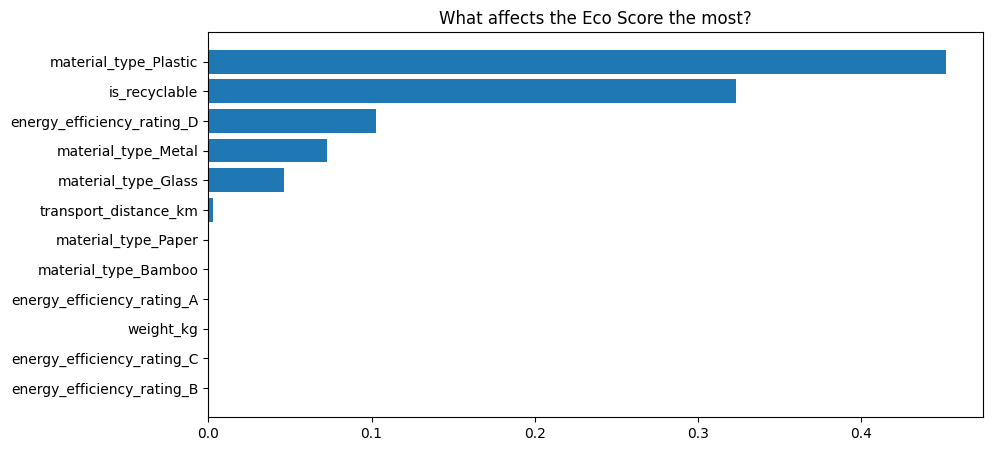

In [20]:
# Saved the model
joblib.dump(model, MODEL_PATH)

# Saved the column names (We need this to know the order of inputs later)
joblib.dump(X.columns.tolist(), COLUMNS_PATH)

print(f"✅ Model saved to {MODEL_PATH}")

plt.figure(figsize=(10,5))
sorted_idx = model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.title("What affects the Eco Score the most?")
plt.show()